# Lecture A07: Good and Bad Controls

Companion notebook for [[Lecture A07 - Good and Bad Controls]]. Prerequisites: [[A01|A01]] through [[A06|A06]].

**Part 1** — Lecture walkthrough: pipe simulation, collider bias (the dangerous one), descendant as proxy, d-separation rules, backdoor criterion

**Part 2** — Applied exercises: collider bias in transaction data, endogenous collider with price band, forensic descendant proxy, backdoor criterion for municipality DAG

**Convention:** 89% credible intervals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from scipy.special import expit
from numpy.linalg import lstsq
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"
C_PURPLE = "#7c3aed"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

def standardize(x):
    return (x - np.nanmean(x)) / np.nanstd(x)

def quap_linear(y, X, prior_sd_beta=0.5, prior_sd_alpha=0.2):
    """General quadratic approximation for standardized linear regression."""
    n, k = X.shape
    def neg_lp(params):
        alpha = params[0]
        betas = params[1:k+1]
        log_s = params[k+1]
        sigma = np.exp(log_s)
        mu = alpha + X @ betas
        ll = np.sum(stats.norm.logpdf(y, mu, sigma))
        lp = stats.norm.logpdf(alpha, 0, prior_sd_alpha)
        lp += sum(stats.norm.logpdf(b, 0, prior_sd_beta) for b in betas)
        lp += stats.expon.logpdf(sigma, scale=1) + log_s
        return -(ll + lp)
    x0 = np.zeros(k + 2); x0[-1] = 0.0
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})
    eps = 1e-5; np_ = k + 2
    hess = np.zeros((np_, np_))
    for i in range(np_):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, gi, eps)
    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(np_) * 0.01
    rng_q = np.random.default_rng(SEED)
    samp = rng_q.multivariate_normal(result.x, cov, size=N_SAMPLES)
    samp[:, -1] = np.exp(samp[:, -1])
    mode = result.x.copy(); mode[-1] = np.exp(mode[-1])
    return {"mode": mode, "samples": samp, "cov": cov}

---

# Part 1: Lecture Walkthrough

## 1. The Pipe: $X \rightarrow Z \rightarrow Y$

$Z$ is a mediator. Conditioning blocks the causal path. For total effects, do NOT condition on mediators.

In [2]:
def simulate_pipe(n=1000, seed=SEED):
    """X -> Z -> Y. Conditioning on Z blocks the causal effect."""
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    z = 0.8 * x + rng.normal(0, 0.5, size=n)
    y = 0.8 * z + rng.normal(0, 0.5, size=n)
    return {"X": x, "Y": y, "Z": z}

pipe = simulate_pipe()

# Without Z (total effect)
X2 = np.column_stack([np.ones(len(pipe["X"])), pipe["X"]])
beta_no_z, _, _, _ = lstsq(X2, pipe["Y"], rcond=None)

# With Z (blocks pipe)
X3 = np.column_stack([np.ones(len(pipe["X"])), pipe["X"], pipe["Z"]])
beta_with_z, _, _, _ = lstsq(X3, pipe["Y"], rcond=None)

print(f"beta_X without Z: {beta_no_z[1]:.3f} (total effect)")
print(f"beta_X with Z:    {beta_with_z[1]:.3f} (direct effect only)")
print(f"beta_Z:           {beta_with_z[2]:.3f} (absorbs the mechanism)")
print(f"\nIncluding Z blocks the indirect path X->Z->Y.")

beta_X without Z: 0.652 (total effect)
beta_X with Z:    0.036 (direct effect only)
beta_Z:           0.774 (absorbs the mechanism)

Including Z blocks the indirect path X->Z->Y.


## 2. The Collider: $X \rightarrow Z \leftarrow Y$

$X$ and $Y$ are independent. Both cause $Z$. Conditioning on $Z$ **creates** spurious association. This is the opposite of forks/pipes.

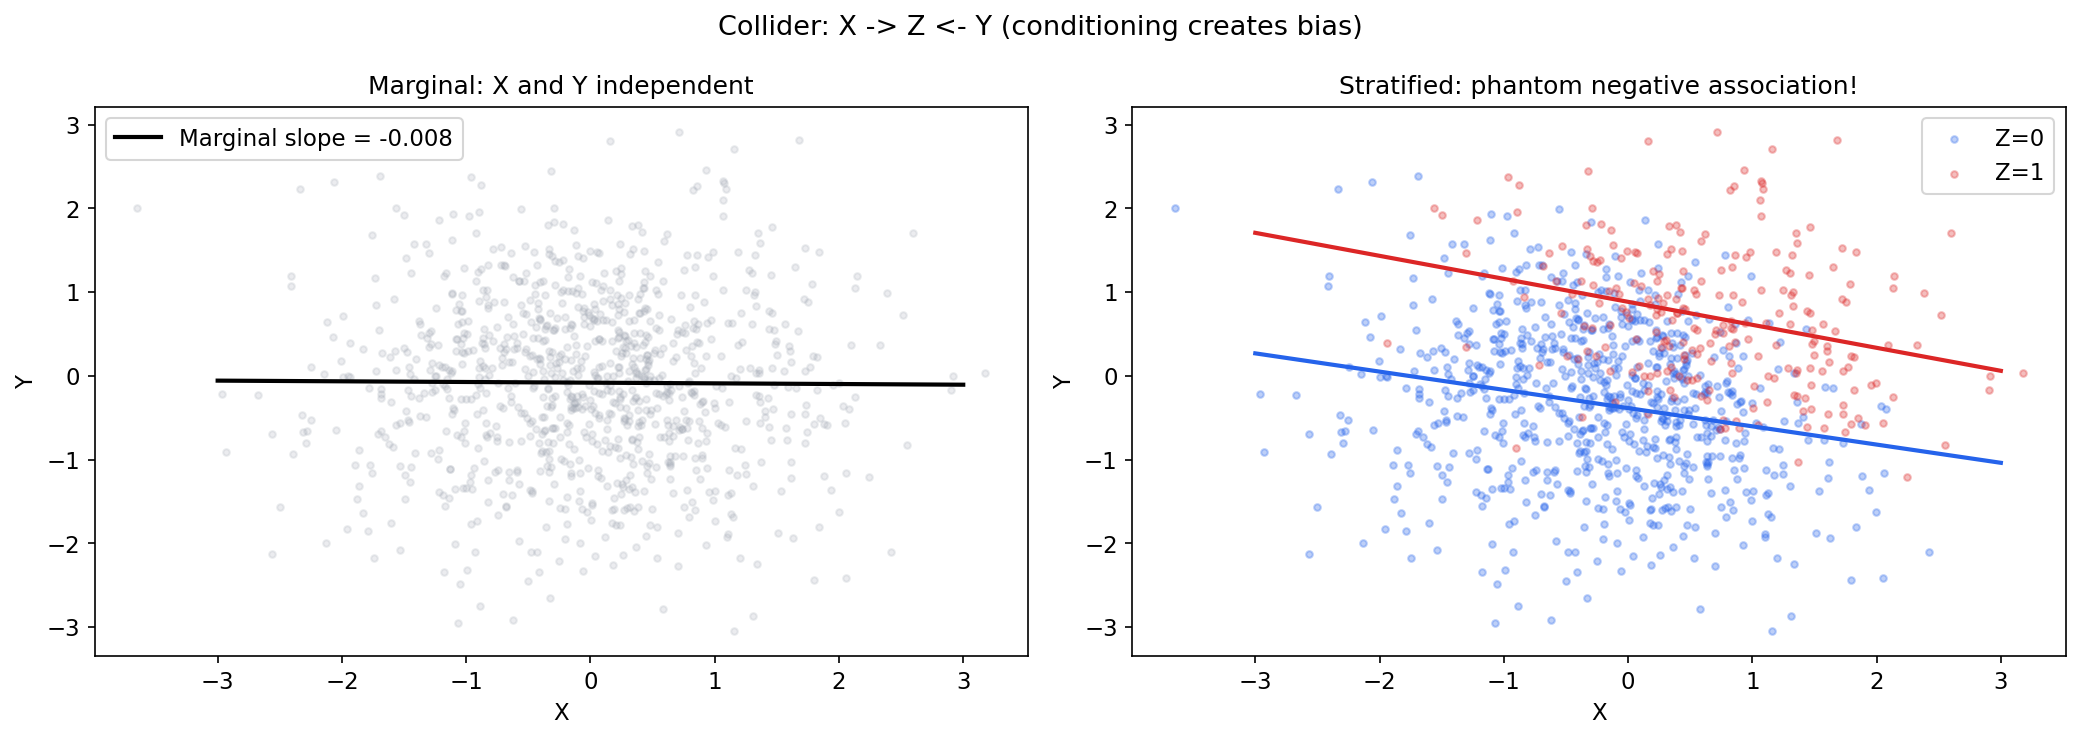

Marginal r: -0.008
r | Z=0: -0.209
r | Z=1: -0.296


In [3]:
def simulate_collider(n=1000, seed=SEED):
    """X -> Z <- Y. Independent X,Y. Conditioning on Z creates association."""
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    y = rng.normal(0, 1, size=n)
    z = rng.binomial(1, expit(2 * x + 2 * y - 2))
    return {"X": x, "Y": y, "Z": z}

coll = simulate_collider()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(-3, 3, 50)

# Marginal
axes[0].scatter(coll["X"], coll["Y"], alpha=0.2, s=10, color=C_PRIOR)
c_all = np.polyfit(coll["X"], coll["Y"], 1)
axes[0].plot(x_line, np.polyval(c_all, x_line), color="black", linewidth=2,
             label=f"Marginal slope = {c_all[0]:.3f}")
axes[0].set_title("Marginal: X and Y independent")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y"); axes[0].legend()

# Stratified
for z_val, color, label in [(0, C_POSTERIOR, "Z=0"), (1, C_LIKELIHOOD, "Z=1")]:
    mask = coll["Z"] == z_val
    axes[1].scatter(coll["X"][mask], coll["Y"][mask], alpha=0.3, s=10, color=color, label=label)
    if mask.sum() > 5:
        c = np.polyfit(coll["X"][mask], coll["Y"][mask], 1)
        axes[1].plot(x_line, np.polyval(c, x_line), color=color, linewidth=2)
axes[1].set_title("Stratified: phantom negative association!")
axes[1].set_xlabel("X"); axes[1].set_ylabel("Y"); axes[1].legend()

plt.suptitle("Collider: X -> Z <- Y (conditioning creates bias)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Marginal r: {np.corrcoef(coll['X'], coll['Y'])[0,1]:.3f}")
for z_val in [0, 1]:
    mask = coll['Z'] == z_val
    if mask.sum() > 5:
        print(f"r | Z={z_val}: {np.corrcoef(coll['X'][mask], coll['Y'][mask])[0,1]:.3f}")

## 3. Selection Bias: Grant Funding

Newsworthiness ($N$) and Trustworthiness ($T$) are independent. Both determine funding. Among funded: $N$ and $T$ negatively correlated.

Same pattern: restaurants (food vs location), real estate (build quality vs location among high-price properties).

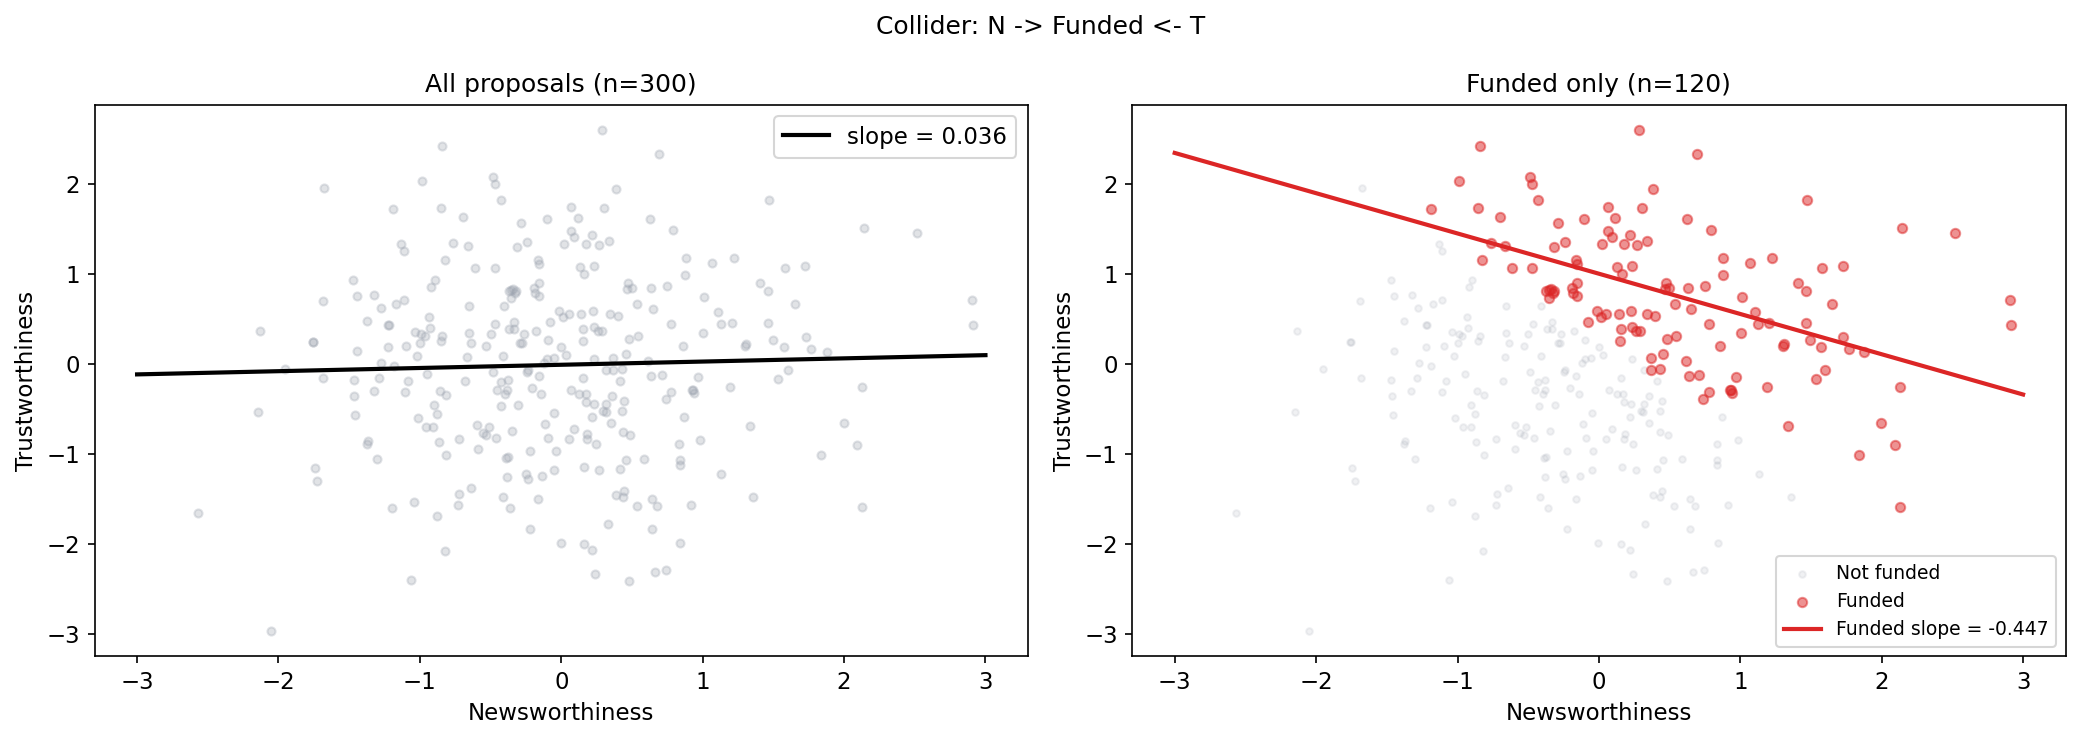

Population r: 0.033
Funded r:     -0.507


In [4]:
rng_g = np.random.default_rng(SEED)
n_proposals = 300
newsworthiness = rng_g.normal(0, 1, size=n_proposals)
trustworthiness = rng_g.normal(0, 1, size=n_proposals)
score = newsworthiness + trustworthiness
funded = score > np.percentile(score, 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_l = np.linspace(-3, 3, 50)

axes[0].scatter(newsworthiness, trustworthiness, alpha=0.3, s=15, color=C_PRIOR)
c_all = np.polyfit(newsworthiness, trustworthiness, 1)
axes[0].plot(x_l, np.polyval(c_all, x_l), color="black", linewidth=2, label=f"slope = {c_all[0]:.3f}")
axes[0].set_title(f"All proposals (n={n_proposals})")
axes[0].set_xlabel("Newsworthiness"); axes[0].set_ylabel("Trustworthiness"); axes[0].legend()

axes[1].scatter(newsworthiness[~funded], trustworthiness[~funded], alpha=0.15, s=10, color=C_PRIOR, label="Not funded")
axes[1].scatter(newsworthiness[funded], trustworthiness[funded], alpha=0.5, s=20, color=C_LIKELIHOOD, label="Funded")
c_f = np.polyfit(newsworthiness[funded], trustworthiness[funded], 1)
axes[1].plot(x_l, np.polyval(c_f, x_l), color=C_LIKELIHOOD, linewidth=2, label=f"Funded slope = {c_f[0]:.3f}")
axes[1].set_title(f"Funded only (n={funded.sum()})")
axes[1].set_xlabel("Newsworthiness"); axes[1].set_ylabel("Trustworthiness"); axes[1].legend(fontsize=9)

plt.suptitle("Collider: N -> Funded <- T", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Population r: {np.corrcoef(newsworthiness, trustworthiness)[0,1]:.3f}")
print(f"Funded r:     {np.corrcoef(newsworthiness[funded], trustworthiness[funded])[0,1]:.3f}")

## 4. The Descendant: Proxy for a Parent

$A$ is caused by $Z$. Conditioning on $A$ partially conditions on $Z$. Strength depends on proxy quality.

If $Z$ is a collider: descendant partially opens it. If $Z$ is a fork: descendant partially deconfounds.

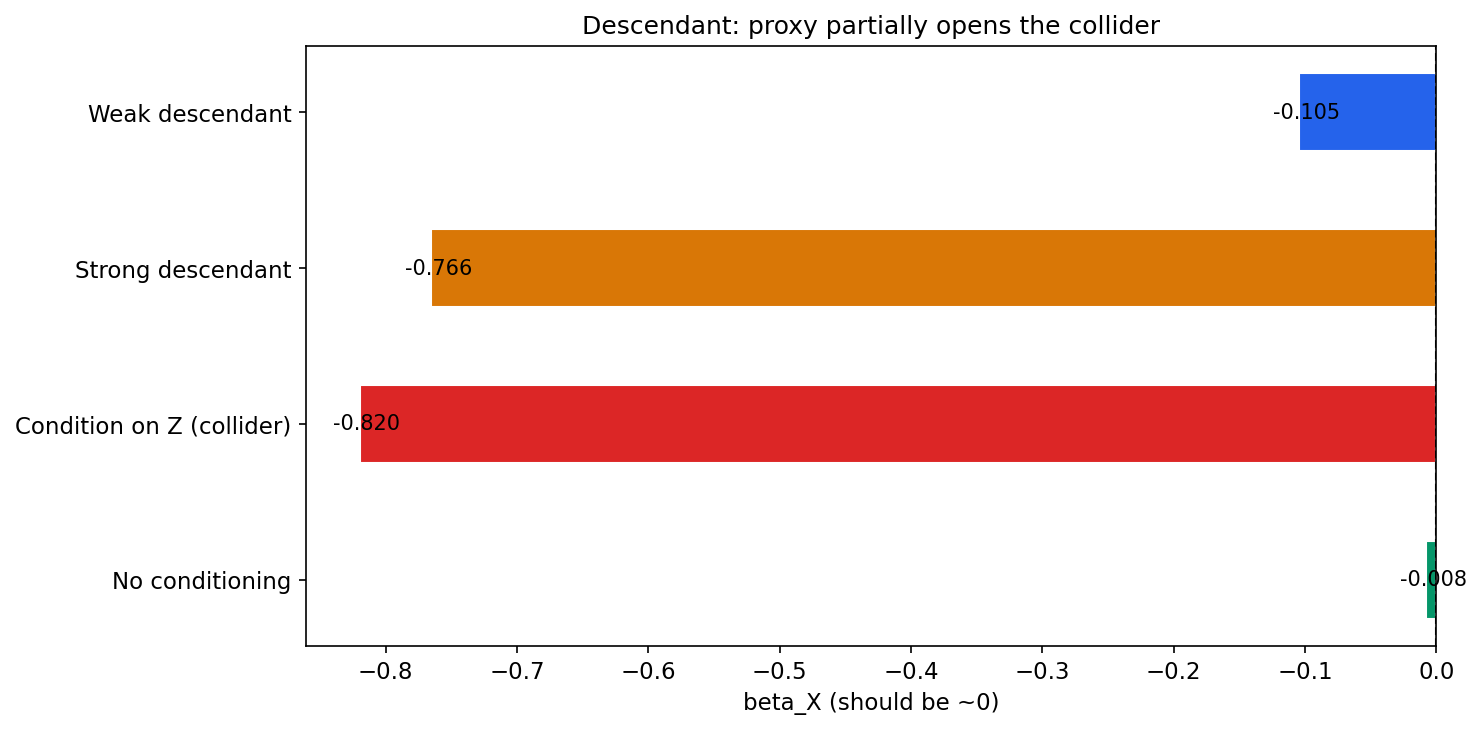

  No conditioning               : beta_X = -0.008
  Condition on Z (collider)     : beta_X = -0.820
  Strong descendant             : beta_X = -0.766
  Weak descendant               : beta_X = -0.105


In [5]:
rng_d = np.random.default_rng(SEED)
n = 1000
x = rng_d.normal(0, 1, size=n)
y = rng_d.normal(0, 1, size=n)
z = x + y + rng_d.normal(0, 0.5, size=n)  # collider
a_strong = z + rng_d.normal(0, 0.3, size=n)
a_weak = z + rng_d.normal(0, 3.0, size=n)

# Compare conditioning strategies
results = {}
for label, X_mat in [
    ("No conditioning", np.column_stack([np.ones(n), x])),
    ("Condition on Z (collider)", np.column_stack([np.ones(n), x, z])),
    ("Strong descendant", np.column_stack([np.ones(n), x, a_strong])),
    ("Weak descendant", np.column_stack([np.ones(n), x, a_weak])),
]:
    beta, _, _, _ = lstsq(X_mat, y, rcond=None)
    results[label] = beta[1]

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(results.keys())
betas = list(results.values())
colors = [C_DATA, C_LIKELIHOOD, C_ACCENT, C_POSTERIOR]

ax.barh(range(4), betas, color=colors, height=0.5, edgecolor="white")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
ax.set_xlabel("beta_X (should be ~0)")
ax.set_title("Descendant: proxy partially opens the collider")
for i, b in enumerate(betas):
    ax.text(b + 0.02 * np.sign(b), i, f"{b:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

for label, b in results.items():
    print(f"  {label:30s}: beta_X = {b:.3f}")

## 5. D-Separation Rules

| Structure | Default | After conditioning |
|-----------|---------|-------------------|
| **Fork** $X \leftarrow Z \rightarrow Y$ | Open | Closed |
| **Pipe** $X \rightarrow Z \rightarrow Y$ | Open | Closed |
| **Collider** $X \rightarrow Z \leftarrow Y$ | Closed | **Opened** |

**Backdoor criterion:** Close all back-door paths without opening colliders.

In [6]:
def is_path_blocked(path_structures, conditioned_on):
    """Check if a path is d-separated given conditioning set."""
    for node_info in path_structures:
        node = node_info["node"]
        structure = node_info["type"]
        if structure in ("fork", "pipe"):
            if node in conditioned_on:
                return True
        elif structure == "collider":
            if node not in conditioned_on:
                return True
    return False

print("Fork X <- Z -> Y:")
print(f"  No conditioning: blocked = {is_path_blocked([{'node': 'Z', 'type': 'fork'}], set())}")
print(f"  Condition on Z:  blocked = {is_path_blocked([{'node': 'Z', 'type': 'fork'}], {'Z'})}")

print("\nCollider X -> Z <- Y:")
print(f"  No conditioning: blocked = {is_path_blocked([{'node': 'Z', 'type': 'collider'}], set())}")
print(f"  Condition on Z:  blocked = {is_path_blocked([{'node': 'Z', 'type': 'collider'}], {'Z'})}")

print("\nPipe X -> Z -> Y:")
print(f"  No conditioning: blocked = {is_path_blocked([{'node': 'Z', 'type': 'pipe'}], set())}")
print(f"  Condition on Z:  blocked = {is_path_blocked([{'node': 'Z', 'type': 'pipe'}], {'Z'})}")

Fork X <- Z -> Y:
  No conditioning: blocked = False
  Condition on Z:  blocked = True

Collider X -> Z <- Y:
  No conditioning: blocked = True
  Condition on Z:  blocked = False

Pipe X -> Z -> Y:
  No conditioning: blocked = False
  Condition on Z:  blocked = True


---

# Part 2: Applied Exercises with Slovenian Data

In [7]:
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

YEAR_MIN = 2022

## Exercise 1: Collider Bias — Selection on Sold Properties

**DAG:** BuildQuality $\rightarrow$ Sold $\leftarrow$ LocationQuality

We only observe completed transactions (Sold=1). Among sold properties, build quality and location may appear negatively correlated.

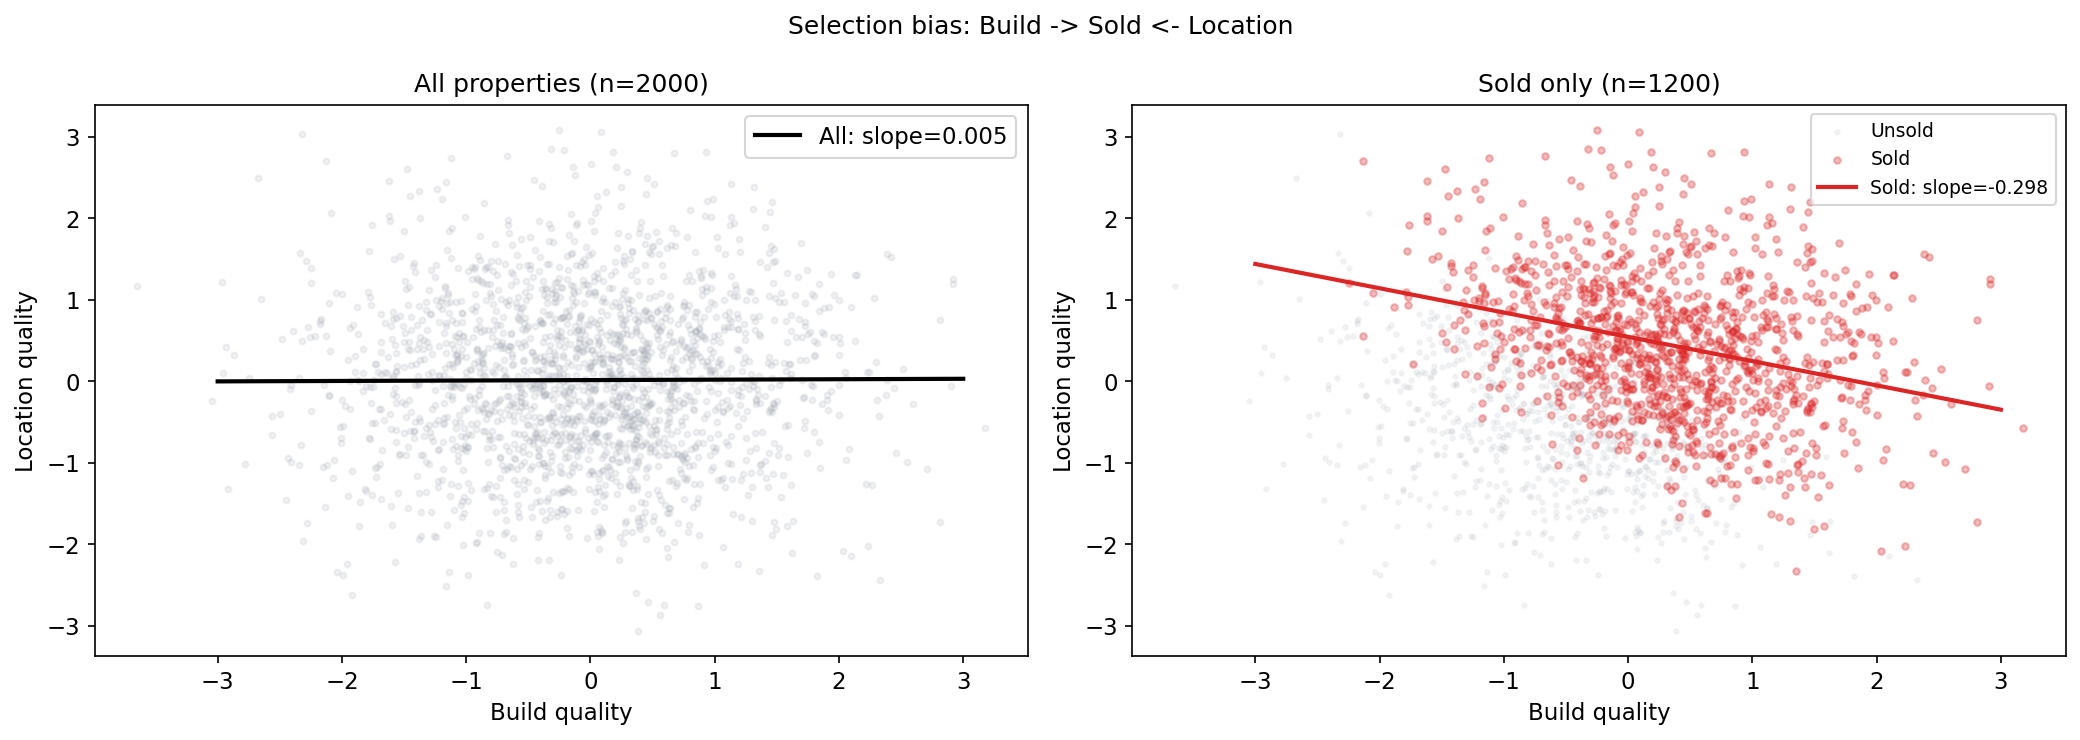

Population r: 0.005
Sold only r:  -0.301

Every hedonic model on transaction data implicitly conditions on Sold=1.


In [8]:
rng_re = np.random.default_rng(SEED)
n_props = 2000
build_quality = rng_re.normal(0, 1, size=n_props)
location_quality = rng_re.normal(0, 1, size=n_props)
desirability = 0.5 * build_quality + 0.5 * location_quality + rng_re.normal(0, 0.3, size=n_props)
sold = desirability > np.percentile(desirability, 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_l = np.linspace(-3, 3, 50)

axes[0].scatter(build_quality, location_quality, alpha=0.15, s=8, color=C_PRIOR)
c_all = np.polyfit(build_quality, location_quality, 1)
axes[0].plot(x_l, np.polyval(c_all, x_l), color="black", linewidth=2, label=f"All: slope={c_all[0]:.3f}")
axes[0].set_title(f"All properties (n={n_props})")
axes[0].set_xlabel("Build quality"); axes[0].set_ylabel("Location quality"); axes[0].legend()

axes[1].scatter(build_quality[~sold], location_quality[~sold], alpha=0.1, s=5, color=C_PRIOR, label="Unsold")
axes[1].scatter(build_quality[sold], location_quality[sold], alpha=0.3, s=10, color=C_LIKELIHOOD, label="Sold")
c_sold = np.polyfit(build_quality[sold], location_quality[sold], 1)
axes[1].plot(x_l, np.polyval(c_sold, x_l), color=C_LIKELIHOOD, linewidth=2, label=f"Sold: slope={c_sold[0]:.3f}")
axes[1].set_title(f"Sold only (n={sold.sum()})")
axes[1].set_xlabel("Build quality"); axes[1].set_ylabel("Location quality"); axes[1].legend(fontsize=9)

plt.suptitle("Selection bias: Build -> Sold <- Location", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Population r: {np.corrcoef(build_quality, location_quality)[0,1]:.3f}")
print(f"Sold only r:  {np.corrcoef(build_quality[sold], location_quality[sold])[0,1]:.3f}")
print("\nEvery hedonic model on transaction data implicitly conditions on Sold=1.")

## Exercise 2: Endogenous Collider — Filtering by Price

**DAG:** Area $\rightarrow$ Price $\leftarrow$ YearBuilt

Filtering to a price band conditions on the collider. Within the band, area and year_built become negatively correlated.

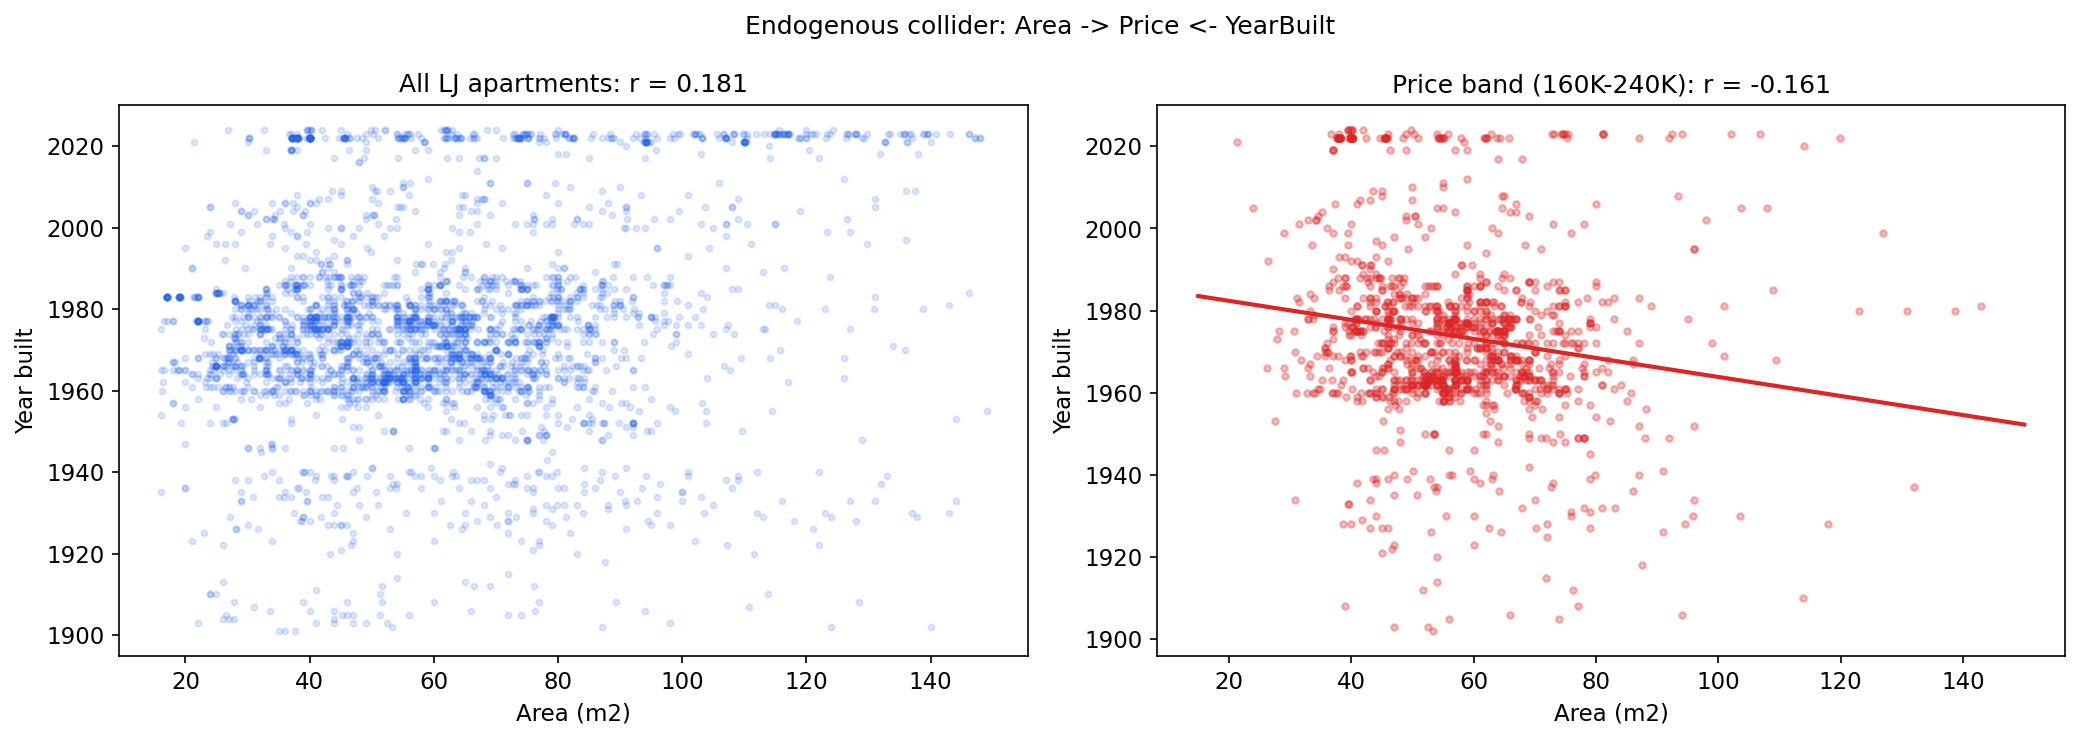

Marginal area-yearbuilt r: 0.181
Within price band r:       -0.161
Filtering by price conditions on the collider.


In [9]:
lj = re[
    (re["year"] >= YEAR_MIN) & (re["municipality"] == "LJUBLJANA")
    & (re["property_type"] == "apartment")
    & re["area_m2"].notna() & re["year_built"].notna() & re["price_eur"].notna()
    & (re["area_m2"] > 15) & (re["area_m2"] < 150)
    & (re["year_built"] > 1900) & (re["year_built"] <= 2025)
].copy()

r_marginal = np.corrcoef(lj["area_m2"], lj["year_built"])[0, 1]

price_med = lj["price_eur"].median()
price_band = lj[(lj["price_eur"] > price_med * 0.8) & (lj["price_eur"] < price_med * 1.2)]
r_cond = np.corrcoef(price_band["area_m2"], price_band["year_built"])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(lj["area_m2"], lj["year_built"], alpha=0.15, s=8, color=C_POSTERIOR)
axes[0].set_title(f"All LJ apartments: r = {r_marginal:.3f}")
axes[0].set_xlabel("Area (m2)"); axes[0].set_ylabel("Year built")

axes[1].scatter(price_band["area_m2"], price_band["year_built"], alpha=0.3, s=10, color=C_LIKELIHOOD)
c_b = np.polyfit(price_band["area_m2"].values, price_band["year_built"].values, 1)
axes[1].plot(np.linspace(15, 150, 50), np.polyval(c_b, np.linspace(15, 150, 50)), color=C_LIKELIHOOD, linewidth=2)
axes[1].set_title(f"Price band ({price_med*0.8/1000:.0f}K-{price_med*1.2/1000:.0f}K): r = {r_cond:.3f}")
axes[1].set_xlabel("Area (m2)"); axes[1].set_ylabel("Year built")

plt.suptitle("Endogenous collider: Area -> Price <- YearBuilt", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Marginal area-yearbuilt r: {r_marginal:.3f}")
print(f"Within price band r:       {r_cond:.3f}")
print("Filtering by price conditions on the collider.")

## Exercise 3: Forensic Audio — ENF SNR as Descendant of True Authenticity

**DAG:** Category $\rightarrow$ TrueAuth $\rightarrow$ ENF_SNR (descendant)

ENF SNR is a noisy proxy for authenticity. AUC measures proxy quality. This is the $C_\text{llr}$ problem.

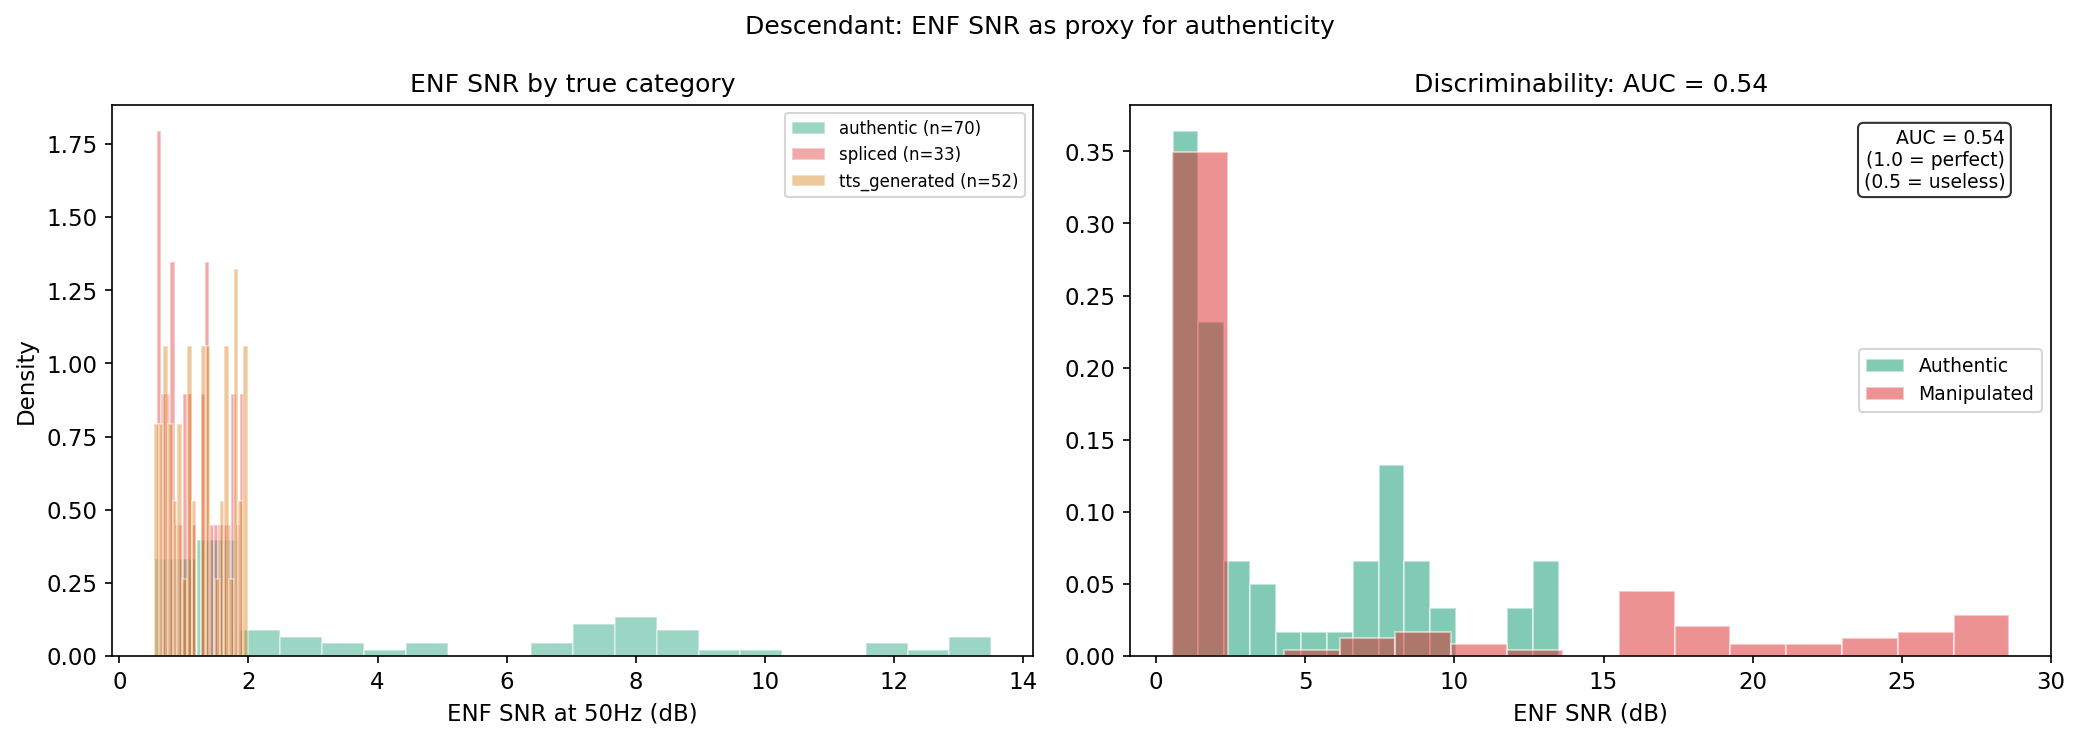

AUC = 0.54: ENF SNR partially discriminates authentic from manipulated.
Cllr calibration measures this proxy quality formally.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cat, color in [("authentic", C_DATA), ("spliced", C_LIKELIHOOD), ("tts_generated", C_ACCENT)]:
    sub = forensic[forensic["category"] == cat]
    vals = sub["enf_snr_50hz"].dropna()
    if len(vals) > 3:
        axes[0].hist(vals, bins=20, density=True, alpha=0.4, color=color,
                     edgecolor="white", label=f"{cat} (n={len(vals)})")
axes[0].set_title("ENF SNR by true category")
axes[0].set_xlabel("ENF SNR at 50Hz (dB)"); axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

auth_enf = forensic.loc[forensic["category"] == "authentic", "enf_snr_50hz"].dropna()
manip_enf = forensic.loc[forensic["is_authentic"] == 0, "enf_snr_50hz"].dropna()

if len(auth_enf) > 3 and len(manip_enf) > 3:
    rng_auc = np.random.default_rng(SEED)
    n_pairs = min(5000, len(auth_enf) * len(manip_enf))
    a_s = rng_auc.choice(auth_enf.values, size=n_pairs)
    m_s = rng_auc.choice(manip_enf.values, size=n_pairs)
    auc = (a_s > m_s).mean() + 0.5 * (a_s == m_s).mean()

    axes[1].hist(auth_enf, bins=15, density=True, alpha=0.5, color=C_DATA, edgecolor="white", label="Authentic")
    axes[1].hist(manip_enf, bins=15, density=True, alpha=0.5, color=C_LIKELIHOOD, edgecolor="white", label="Manipulated")
    axes[1].set_title(f"Discriminability: AUC = {auc:.2f}")
    axes[1].set_xlabel("ENF SNR (dB)")
    axes[1].legend(fontsize=9)
    axes[1].text(0.95, 0.85, f"AUC = {auc:.2f}\n(1.0 = perfect)\n(0.5 = useless)",
                 transform=axes[1].transAxes, ha="right", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Descendant: ENF SNR as proxy for authenticity", fontsize=12)
plt.tight_layout()
plt.show()

print(f"AUC = {auc:.2f}: ENF SNR partially discriminates authentic from manipulated.")
print("Cllr calibration measures this proxy quality formally.")

## Exercise 4: Backdoor Criterion — Municipality Price DAG

**Paths from TxnCount to Price:**
1. TxnCount $\rightarrow$ Price (front door) — don't block
2. TxnCount $\leftarrow$ Salary $\rightarrow$ Price (back door, fork) — block by conditioning on Salary

**Adjustment set:** {Salary}

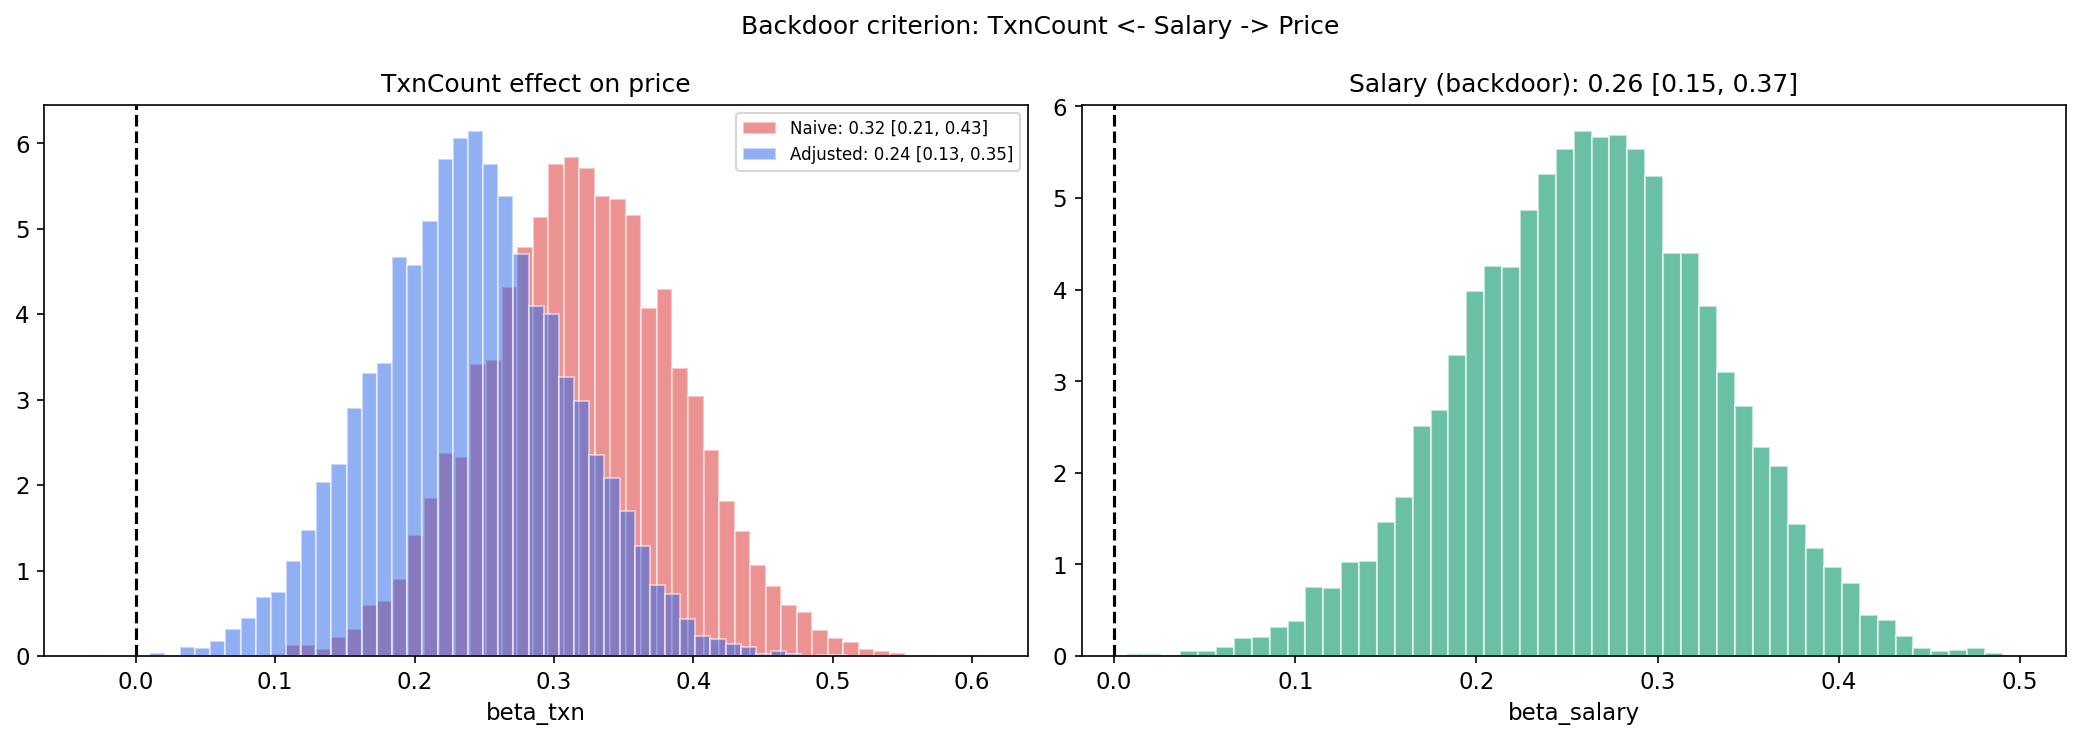

Naive beta_txn:    0.321 (confounded)
Adjusted beta_txn: 0.240 (salary blocked)
beta_salary:       0.263


In [11]:
latest_year = mun["year"].max()
mun_clean = mun[
    (mun["year"] == latest_year)
    & mun["avg_gross_salary"].notna()
    & mun["median_price_m2"].notna()
    & mun["transaction_count"].notna()
].copy()

mun_clean["sal_s"] = standardize(mun_clean["avg_gross_salary"].values)
mun_clean["pri_s"] = standardize(mun_clean["median_price_m2"].values)
mun_clean["txn_s"] = standardize(mun_clean["transaction_count"].values)

fit_naive = quap_linear(mun_clean["pri_s"].values, mun_clean["txn_s"].values[:, None])
beta_naive = fit_naive["samples"][:, 1]

X_adj = np.column_stack([mun_clean["txn_s"].values, mun_clean["sal_s"].values])
fit_adj = quap_linear(mun_clean["pri_s"].values, X_adj)
beta_adj = fit_adj["samples"][:, 1]
beta_sal = fit_adj["samples"][:, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ci_n = np.percentile(beta_naive, [5.5, 94.5])
ci_a = np.percentile(beta_adj, [5.5, 94.5])
axes[0].hist(beta_naive, bins=50, density=True, alpha=0.5, color=C_LIKELIHOOD, edgecolor="white",
             label=f"Naive: {beta_naive.mean():.2f} [{ci_n[0]:.2f}, {ci_n[1]:.2f}]")
axes[0].hist(beta_adj, bins=50, density=True, alpha=0.5, color=C_POSTERIOR, edgecolor="white",
             label=f"Adjusted: {beta_adj.mean():.2f} [{ci_a[0]:.2f}, {ci_a[1]:.2f}]")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("TxnCount effect on price")
axes[0].set_xlabel("beta_txn"); axes[0].legend(fontsize=8)

ci_s = np.percentile(beta_sal, [5.5, 94.5])
axes[1].hist(beta_sal, bins=50, density=True, alpha=0.6, color=C_DATA, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title(f"Salary (backdoor): {beta_sal.mean():.2f} [{ci_s[0]:.2f}, {ci_s[1]:.2f}]")
axes[1].set_xlabel("beta_salary")

plt.suptitle("Backdoor criterion: TxnCount <- Salary -> Price", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Naive beta_txn:    {beta_naive.mean():.3f} (confounded)")
print(f"Adjusted beta_txn: {beta_adj.mean():.3f} (salary blocked)")
print(f"beta_salary:       {beta_sal.mean():.3f}")

---

# Key Takeaways

1. **The collider is the most dangerous confound.** Conditioning *creates* association where none existed. Grant funding, property transactions, forensic databases — all involve implicit collider conditioning.

2. **Selection bias is collider bias.** Every hedonic model conditions on Sold=1. Every forensic system trained on submitted recordings conditions on submission. Understanding this changes interpretation.

3. **Descendants are noisy proxies.** ENF SNR partially separates authentic from manipulated (AUC measures this). $C_\text{llr}$ formally quantifies proxy quality for forensic LRs.

4. **The backdoor criterion replaces heuristics.** List paths, classify front/back, close back doors without opening colliders. For municipality prices: condition on salary to block the fork.

5. **Endogenous colliders lurk in filtering.** Filtering Ljubljana apartments by price band creates phantom area-yearbuilt correlation. Any subsetting on a downstream variable risks collider bias.

6. **One model, one estimand.** The Table 2 Fallacy: reading every coefficient as causal. Each predictor has a different role. The DAG determines interpretation.

**Next:** [[Lecture A08]] introduces overfitting, information criteria, and model comparison.